# Loan Application Fraud EDA

This notebook reviews the synthetic loan application dataset and highlights the business patterns that separate likely fraud from normal applications. The goal is to support a credit risk discussion with clear visuals and plain-language takeaways.

## 1. DATASET OVERVIEW

We begin with a simple quality check. This helps us confirm the file loaded correctly, understand what information is available for each applicant, and spot any missing values that could affect downstream risk decisions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)

DATA_PATH = Path("../data/raw/loan_applications.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

df.head()

Dataset shape: (10000, 16)

Column names:
['applicant_id', 'full_name', 'ssn', 'date_of_birth', 'address', 'employer_name', 'annual_income', 'credit_score', 'loan_amount', 'loan_purpose', 'email', 'phone_number', 'time_at_address_months', 'time_at_employer_months', 'num_recent_inquiries', 'is_fraud']

Data types:
applicant_id               object
full_name                  object
ssn                        object
date_of_birth              object
address                    object
employer_name              object
annual_income               int64
credit_score                int64
loan_amount                 int64
loan_purpose               object
email                      object
phone_number               object
time_at_address_months      int64
time_at_employer_months     int64
num_recent_inquiries        int64
is_fraud                    int64
dtype: object

Missing values per column:
applicant_id               0
full_name                  0
ssn                        0
date_of_birt

,applicant_id,full_name,ssn,date_of_birth,address,employer_name,annual_income,credit_score,loan_amount,loan_purpose,email,phone_number,time_at_address_months,time_at_employer_months,num_recent_inquiries,is_fraud
0,APP-000001,Allison Hill,589-21-7912,1962-05-06,"819 Johnson Course, East William, AK 74064",North Ridge Logistics,48191,537,19000,debt_consolidation,jennifermiles@example.com,379-402-6542,68,63,3,0
1,APP-000002,Phillip Garcia,643-38-8359,1971-12-21,"9407 Teresa Lane Apt. 849, Barbaraland, AZ 87174",Greenline Telecom,161485,550,52000,auto,kendragalloway@example.org,164-752-5534,149,56,2,1
2,APP-000003,Melinda Jones,568-22-6881,1966-09-05,"76483 Cameron Trail, East Lydiamouth, MO 35594",Crescent Energy,80110,693,10500,education,clarksherri@example.net,537-672-4238,77,45,3,0
3,APP-000004,Nicole Patterson,496-83-4150,1956-04-02,"28710 Eric Estate Suite 916, Carlsonmouth, NC ...",Silver Oak Pharmacy,92231,774,43500,home_improvement,frazierdanny@example.net,451-462-7048,37,102,0,0
4,APP-000005,Katie Rodriguez,636-30-7065,1972-10-19,"52880 Burns Creek, Natashaport, IA 08093",Crescent Energy,63806,745,18500,small_business,nataliearroyo@example.org,718-227-8248,224,65,2,0


## 2. CLASS DISTRIBUTION

This view shows the balance between normal applications and flagged fraud cases. It tells us whether fraud is a rare edge case or a large enough share of the book that it deserves close operational attention.

C:\Users\zaina\AppData\Local\Temp\ipykernel_13408\1339051401.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


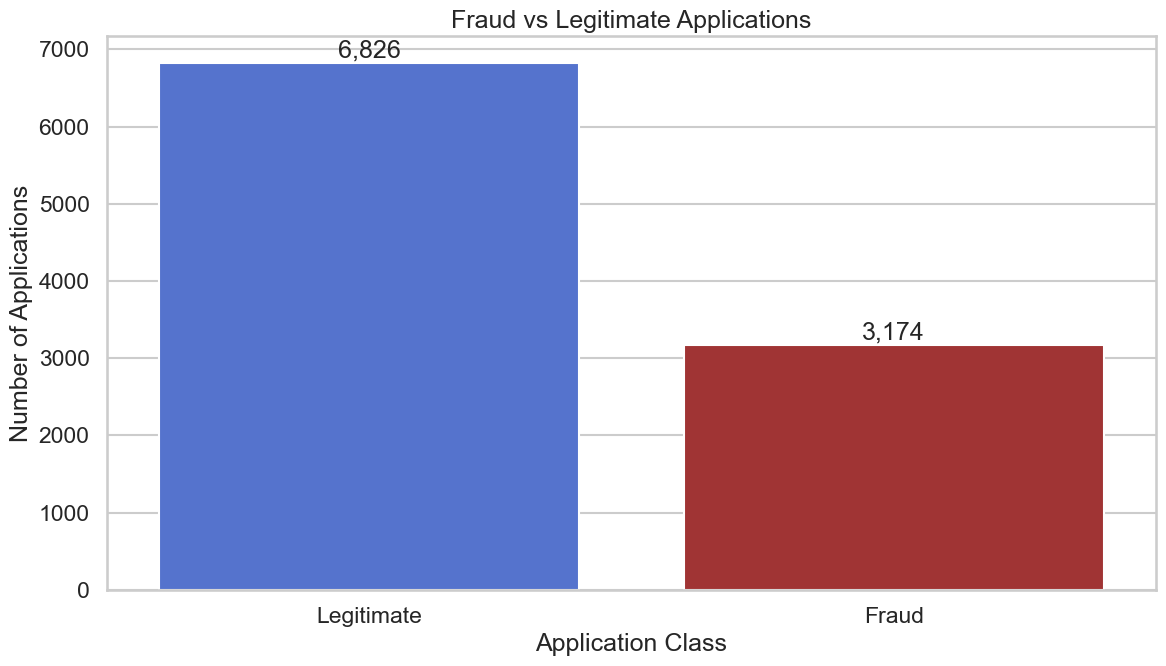

Class percentages:
Legitimate: 68.26%
Fraud: 31.74%


In [2]:
class_counts = df["is_fraud"].value_counts().sort_index()
class_labels = {0: "Legitimate", 1: "Fraud"}
plot_data = class_counts.rename(index=class_labels)
class_percentages = (class_counts / len(df) * 100).round(2)

ax = sns.barplot(
    x=plot_data.index,
    y=plot_data.values,
    palette=["royalblue", "firebrick"]
)
ax.set_title("Fraud vs Legitimate Applications")
ax.set_xlabel("Application Class")
ax.set_ylabel("Number of Applications")

for i, value in enumerate(plot_data.values):
    ax.text(i, value + max(plot_data.values) * 0.01, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()

print("Class percentages:")
for class_value, pct in class_percentages.items():
    print(f"{class_labels[class_value]}: {pct:.2f}%")

## 3. CREDIT SCORE ANALYSIS

Credit score is one of the clearest signals in consumer lending. By comparing score distributions for fraud and non-fraud applications, we can see whether suspicious files cluster around unusual borrower quality profiles.

C:\Users\zaina\AppData\Local\Temp\ipykernel_13408\3917305865.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


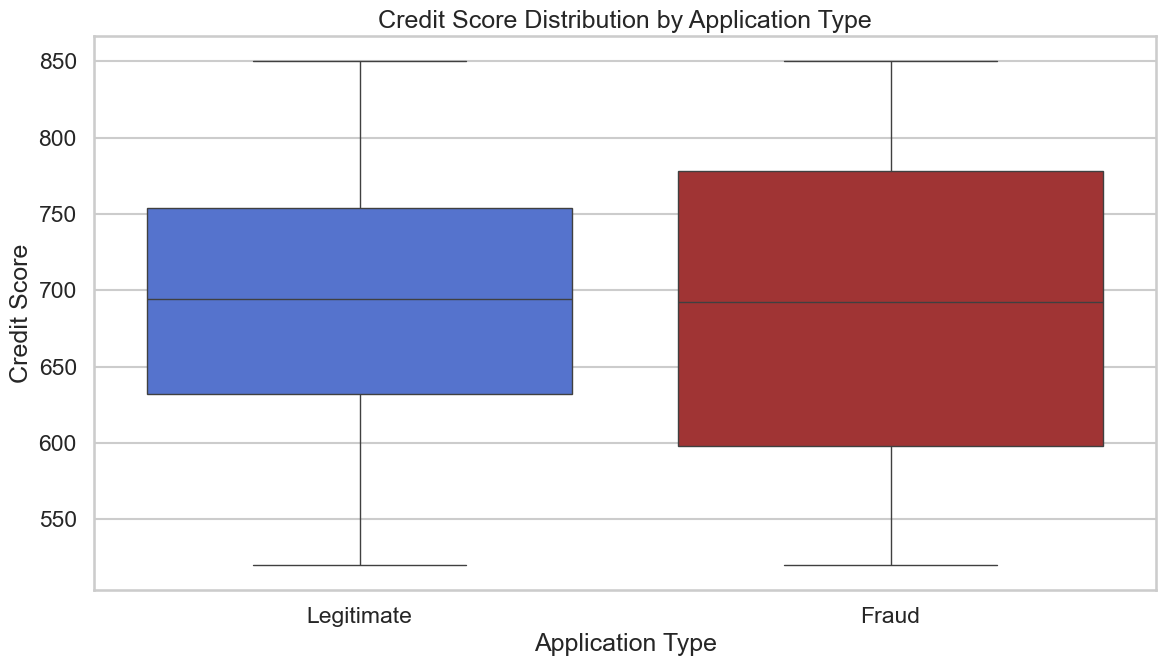

In [3]:
plot_df = df.copy()
plot_df["application_type"] = plot_df["is_fraud"].map({0: "Legitimate", 1: "Fraud"})

ax = sns.boxplot(
    data=plot_df,
    x="application_type",
    y="credit_score",
    palette={"Legitimate": "royalblue", "Fraud": "firebrick"}
)
ax.set_title("Credit Score Distribution by Application Type")
ax.set_xlabel("Application Type")
ax.set_ylabel("Credit Score")
plt.tight_layout()
plt.show()

## 4. INCOME VS LOAN AMOUNT

This chart compares what applicants say they earn against how much they want to borrow. It helps us spot files where the requested loan looks too large for the stated income, which is often an early warning sign of misrepresentation.

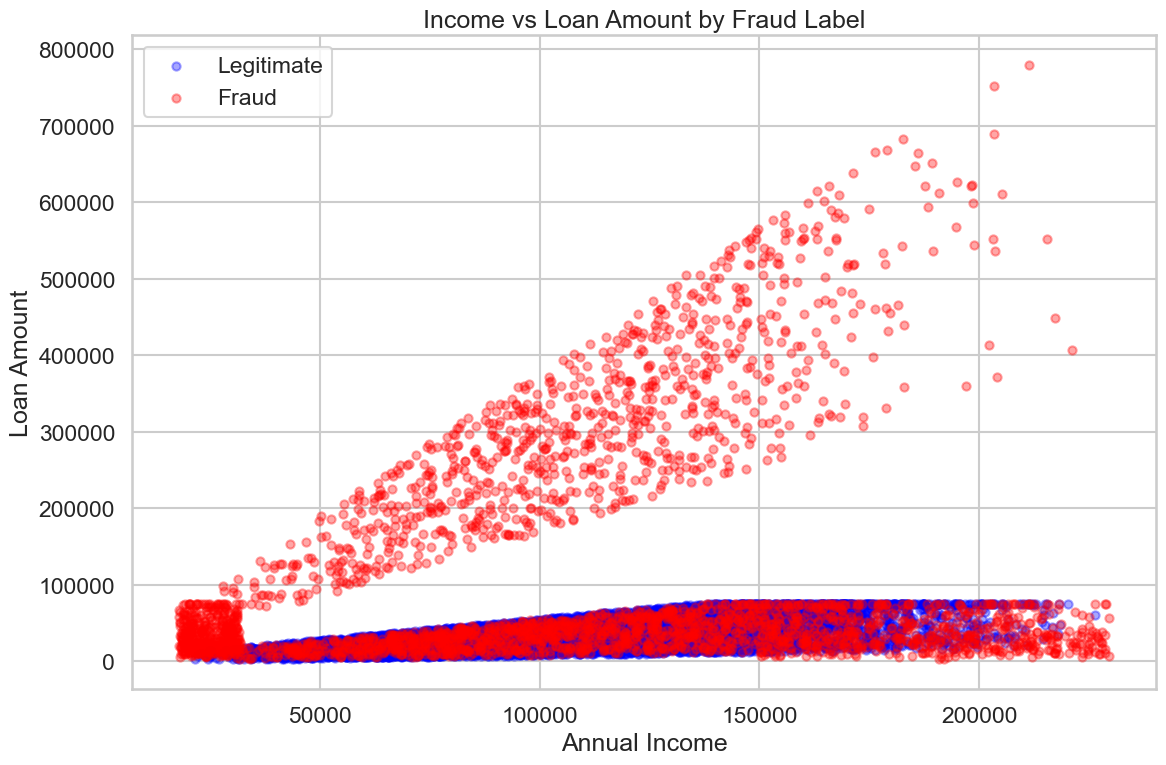

In [4]:
color_map = {0: "blue", 1: "red"}
label_map = {0: "Legitimate", 1: "Fraud"}

plt.figure(figsize=(12, 8))
for class_value in [0, 1]:
    subset = df[df["is_fraud"] == class_value]
    plt.scatter(
        subset["annual_income"],
        subset["loan_amount"],
        c=color_map[class_value],
        alpha=0.35,
        s=35,
        label=label_map[class_value]
    )

plt.title("Income vs Loan Amount by Fraud Label")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.legend()
plt.tight_layout()
plt.show()

## 5. CORRELATION HEATMAP

The heatmap gives us a portfolio-level view of which numeric fields move most closely with fraud outcomes. In business terms, it highlights which borrower or application characteristics deserve the most attention when setting review rules.

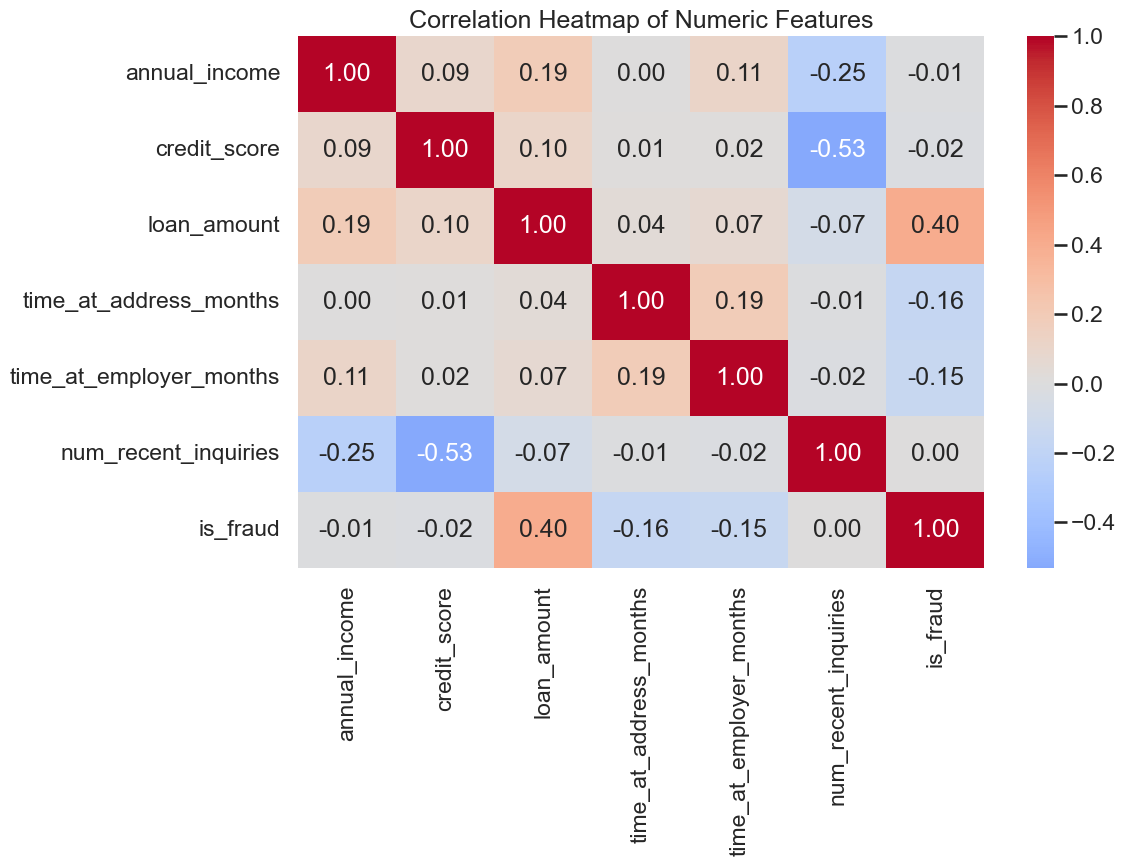

Numeric features most correlated with is_fraud:
loan_amount                0.404799
time_at_address_months    -0.161695
time_at_employer_months   -0.153706
credit_score              -0.019563
annual_income             -0.012546
num_recent_inquiries       0.004925
Name: is_fraud, dtype: float64


In [5]:
numeric_df = df.select_dtypes(include=[np.number]).copy()
corr_matrix = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

fraud_corr = corr_matrix["is_fraud"].drop("is_fraud").sort_values(key=lambda s: s.abs(), ascending=False)
print("Numeric features most correlated with is_fraud:")
print(fraud_corr.head(8))

## 6. TOP FRAUD SIGNALS

This final section translates the data into practical risk indicators. We compare fraud and legitimate applications feature by feature and rank the signals with the biggest separation, helping the committee focus on the patterns most worth monitoring.

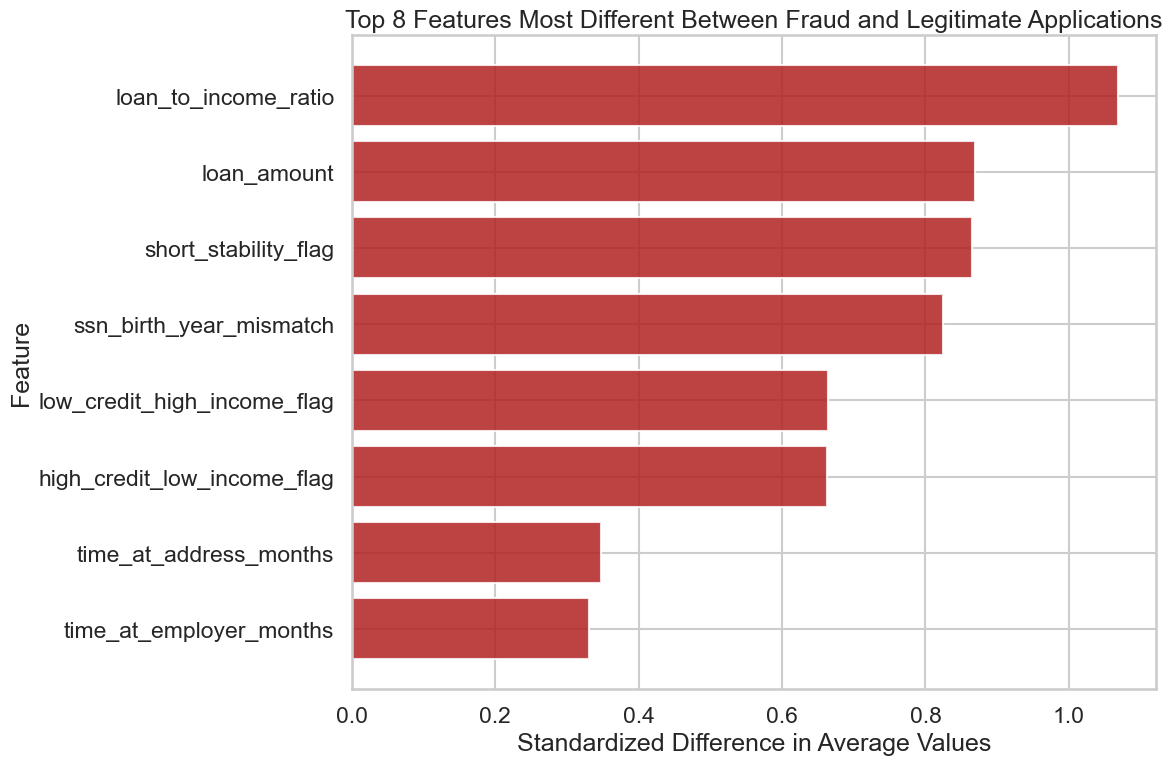

Top 8 fraud signals by standardized difference:
loan_to_income_ratio           1.068100
loan_amount                    0.869623
short_stability_flag           0.864329
ssn_birth_year_mismatch        0.824490
low_credit_high_income_flag    0.663900
high_credit_low_income_flag    0.662922
time_at_address_months         0.347366
time_at_employer_months        0.330203
dtype: float64


In [6]:
eda_df = df.copy()

eda_df["birth_year"] = pd.to_datetime(eda_df["date_of_birth"]).dt.year
eda_df["ssn_area"] = eda_df["ssn"].str.split("-").str[0].astype(int)
eda_df["ssn_encoded_decade"] = ((eda_df["ssn_area"] - 100) // 70).clip(lower=0)
eda_df["birth_decade_digit"] = (eda_df["birth_year"] // 10) % 10
eda_df["ssn_birth_year_mismatch"] = (eda_df["ssn_encoded_decade"] != eda_df["birth_decade_digit"]).astype(int)
eda_df["loan_to_income_ratio"] = eda_df["loan_amount"] / eda_df["annual_income"].replace(0, np.nan)
eda_df["short_stability_flag"] = (
    (eda_df["time_at_address_months"] <= 3)
    & (eda_df["time_at_employer_months"] <= 3)
).astype(int)
eda_df["duplicate_ssn_name_flag"] = eda_df.groupby("ssn")["full_name"].transform("nunique").gt(1).astype(int)
eda_df["high_credit_low_income_flag"] = (
    (eda_df["credit_score"] >= 790)
    & (eda_df["annual_income"] <= 32000)
).astype(int)
eda_df["low_credit_high_income_flag"] = (
    (eda_df["credit_score"] <= 565)
    & (eda_df["annual_income"] >= 150000)
).astype(int)

signal_features = [
    "loan_to_income_ratio",
    "ssn_birth_year_mismatch",
    "short_stability_flag",
    "duplicate_ssn_name_flag",
    "high_credit_low_income_flag",
    "low_credit_high_income_flag",
    "credit_score",
    "annual_income",
    "loan_amount",
    "time_at_address_months",
    "time_at_employer_months",
    "num_recent_inquiries",
]

group_means = eda_df.groupby("is_fraud")[signal_features].mean()
std_scale = eda_df[signal_features].std().replace(0, 1)
mean_diff = ((group_means.loc[1] - group_means.loc[0]).abs() / std_scale).sort_values(ascending=False)
top_8 = mean_diff.head(8).sort_values(ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(top_8.index, top_8.values, color="firebrick", alpha=0.85)
plt.title("Top 8 Features Most Different Between Fraud and Legitimate Applications")
plt.xlabel("Standardized Difference in Average Values")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 8 fraud signals by standardized difference:")
print(top_8.sort_values(ascending=False))